CASO PRATICO: CLASSIFICAZIONE IMMAGINI CON TRANSFER LEARNING

Classificatore di fiori con MobileNetV2

- Acquisizione dei dati: dataset reali che vivono fuori dalle librerie standard
- Asportare la testa di un modello preaddestrato e poi innesto di un nuovo modello decisionale con nuovi layer densi
- Addestramento specializzato e valutazione delle metriche su domini ristretti, per validare il nostro modello

Nel mondo reale ci possiamo trovare a dover scaricare dati provenienti da repository remoti o cloud storage. 
Inoltre i dati sono sparsi e sporchi, potreste dover scaricare migliaia di immagini da un server remoto, o organizzare foto scattate da noi in ufficio.
Il primo esempio del transfer learning applicato nella realtà consiste nel mappare una struttura di cartelle locale o remota in un oggetto 'Dataset' compatibile con le pipeline di TensorFlow, garantendo la correta associazione tra immagini e label 

Strutturazione dei dati
Dal file compresso alla memoria tensoriale.
- La funzione tf.keras.utils.get_file permete di automatizzare il download e la decompressione di archivi remoti, gestendo la cache locale per evitare download ridondanti. Scarica e scompatta tutto per noi.
- Il metodo 'image_dataset_from_directory' trasforma automaticamente una gerarchia di cartelle in un generatore di batch, dove il nome della cartella funge da etichetta della classe/del dato. (esempio cartella cani e cartella gatti con dentro le varie immagini)
- La normalizzazione dei canali colore e il ridimensionamento delle immagini devono essere coerenti con i requisiti del modello pre-addestrato che andremo a utilizzare. 
La dimensione delle immagini e la normalizzazione dei nostri dati devono essere identiche a quelle del dataset che stiamo scaricando.
- La rappresentazione formale di un set di dati specializzato associa ogni input a una classe specifica del nuovo dominio.

Non vogliamo che la nostra GPU resti ferma ad aspettare che il disco legga un'immagine, per fare questo applichiamo i metodi 'cache()' (per tenere i dati pronti in ram) e 'prefetch()' (per preparare il prossimo batch mentre il modello sta ancora studiando quello attuale)
E' possibile inserire layer di pre-elaborazione (data augmentation integrata) direttamente all'inizio della rete per generare variazioni sintetiche dei dati durante il caricamento. 
Il caricatore Keras consente di separare automaticamente una porzione del dataset per il monitoraggio della generalizzazione durante la fase di specializzazione (validation split).

Nel transfer learning il collo di bottiglia poi si sposta, non è più l'inizzializzazione del modello (i pesi non devono convergere da zero), ma la capacità della CPU di alimentare la GPU con immagini già processate. Non stiamo aspettando che i pesi convergano da zero ma che la CPU alimenti la GPU, ottimizzare questo passaggio significa garantire che il processo di fine-tuning sia continuo e accurato, ed i tempi di addestramento migliorano drasticamente.
Ora che i dati scorrono è il momento di opeare sul modello

Ingegneria della Nuova Testa
Sostituzione chirurgica dei layer di output
Un modello pre-addestrato come MobileNet (esperto che distingue mille cose) o VGG16 termina con un layer densi progettato per mille classi. Per il nostro compito specifico, dobbiamo rimuovere questa parte (detta testa, ultimo strato denso) e sostituirla con un'architettura adatta al nostro numero di categorie.
Questo processo richiede di isolare l'output dell'ultimo layer convoluzionale e collegarlo a un nuovo blocco di classificazione che inizieremo ad addestrare partendo da pesi casuali.

Innesto del Classficatore
Adattamento della dimensionalità
- Il layer 'GlobalAveragePooling2D' è essenziale per collassare le mappe di feature spaziali in un vettore monodimensionale preservando le informazioni salienti. E' come un traduttore che riassume un intero libro in una sola pagina di punti chiave.
- Aggiungendo uno o più layer 'Dense' intermedi con attivazone ReLu per permettere alla rete di imparare le relazioni non lineari specifiche del nuovo dataset. Questi layer partono con pesi casuali e sono pronti ad interpretare segnali che arrivano dalla base convoluzionale già addestrata
- Il layer di output finale deve essere un numero di neuroni pari al numero di classi del nostro dataset personalizzato, solitamente accopiato a una funzione softmax.
- L'output della base convoluzionale viene trasformato nel vettore di probabilità finale tramite pesi addestrabili dedicati.

Blocco dei parametri.
Impostando la proprietà 'trainable' della base a false, garantisce che i pesi estrattori di feature non vengano distrutti dai gradienti iniziali elevati. Con questo mettiamo lucchetti ai filtri che hanno imparato a vedere il mondo, perchè all'inizio i nostri nuovi layer densi spareranno gradienti casuali e caotici, se non congelassimo la base questi feedback di errori distruggerebbero istantaneamente tutta la conoscenza accumulata nel modello base. Quindi inizialmente vogliamo che solo la nuova testa impari a leggere mentre il corpo rimane un osservatore immobile
Congelare la base è come proteggere un database prezioso di sola lettura: permettiamo solo letture (inferenza) mentre scriviamo i nuovi dati (addestramento) in un tabella separata (la nostra testa innestata).
Dovremmo vedere milioni di parametri classificati come non addestrabili e poche migliaia classificati come addestrabili.
Sfruttando l'API funzionale per collegare l'output della base al nuovo classificatore, creando un modello unico che incapsula entrambe le fasi.

Una volta stabilizzata l'architettura, entriamo nel vivo dell'addestramento.


Ciclo di Training e Metriche
Monitoraggio della specializzazione
Dopo la chirurgia architettonica, procediamo all'addestramento. Vedremo come gestire questo processo e come interpretare i risultati dell'esercizio che svolgeremo a breve.
L'addestramento nel transfer learning è solitamente molto più rapido di quello standard, poichè la rete deve imparare solo a interpretare feature che sa già riconoscere perfettamente.
Quindi l'accuratezza salirà molto più velocemente del solito, questo perchè non deve capire cos'è un cerchio o altre forme, deve solo collegare quelle forme alla parola margherita o rosa. E' una fase di specializzazione accellerata.

Ottimizzazione Finalizzata
Raggiungere la convergenza
- Usiamo un ottimizzatore come Adam con un learning rate standard, poichè stiamo addestrando solo pochi layer finali partendo da zero
- La funzione di perdita 'SparseCategoricalCrossentropy' è la scelta ideale quando le label sono fornite come numeri interi dal caricatore di directory
- Monitoriamo costantemente l'accuratezza di validazione per assicurarci che la testa si stia adattando bene senza andar in overfitting sui pochi campioni disponibili.
- Il progresso del modello si  misura attraverso la riduzione della divergenza tra la distribuzione predetta e quella reale.

Analisi Post-Training
- Curve di apprendimento: Analiziamo i grafici di loss e accuracy per decidere se il modello è pronto per il fine-tuning della base o se la testa ha già raggiunto il plateau.
- Matrice di confusione: E' fondamentale valutare quali classi specifiche del nuovo dataset vengono confuse più spesso dal modello specializzato
- Valutazione su Test Set: L'accuratezza finale viene calcolata su dati che il modello non  ha mai visto nè durante il training della testa nè durante la validazione.

Verso la Produzione
Verifica della robustezza
Il transfer learning ci permette di passare da un'idea a un prototipo funzionante in poche ore di lavoro effettivo sul codice.
Tramite le tecniche di deploy le architetture specializzate possono essere salvate e distribuite.

Questa capacità di stare sulle spalle dei giganti è ciò che permette alla startup o ricercatori indipendneti, di competere con grandi laboratori, portando l'ai in ogni nicchia del sapere umano

Dataset scaricato in: C:\Users\uberti\.keras\datasets\flower_photos
Found 3670 files belonging to 1 classes.
Using 2569 files for training.
Found 3670 files belonging to 1 classes.
Using 1101 files for validation.
Reloading Tuner from tuning_logs\flower_classification_2025\tuner0.json
--- Ricerca Bayesiana del miglior set di Iperparametri ---
--- Addestramento finale con LR: 0.0001890102042364536 ---
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5990 - loss: 1.0361 
Epoch 1: val_accuracy improved from None to 0.99632, saving model to best_model_2025.keras

Epoch 1: finished saving model to best_model_2025.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.8077 - loss: 0.5473 - val_accuracy: 0.9963 - val_loss: 0.0947 - learning_rate: 1.8901e-04
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.9901 - loss: 0.1012
Epoch 2: val_accuracy improved from 0.99632 to 1.00000, saving model to best_model_2025.keras

Epoch 2: finished saving model to best_

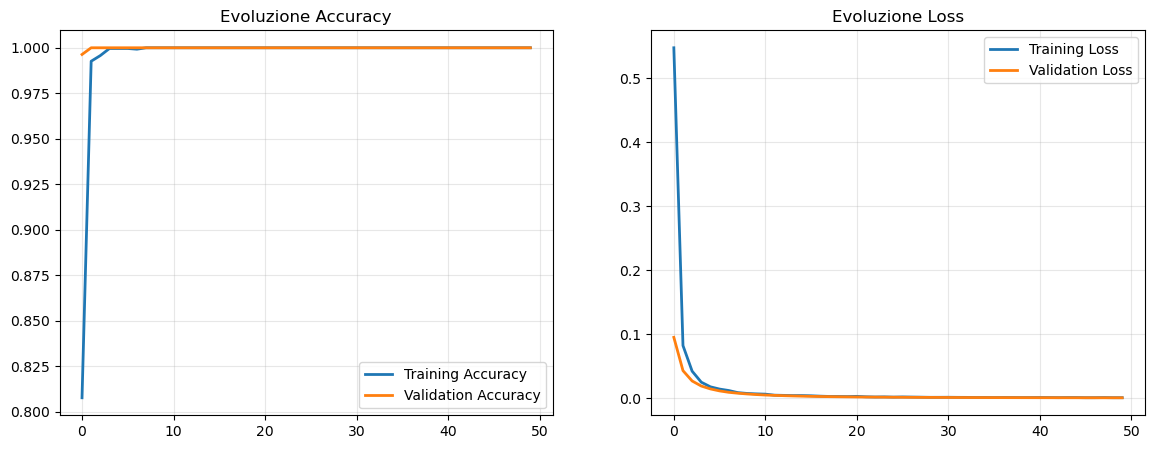

--- Conversione in TFLite (8-bit Quantization) ---
INFO:tensorflow:Assets written to: C:\Users\uberti\AppData\Local\Temp\tmpsi7ma_h6\assets


INFO:tensorflow:Assets written to: C:\Users\uberti\AppData\Local\Temp\tmpsi7ma_h6\assets


Saved artifact at 'C:\Users\uberti\AppData\Local\Temp\tmpsi7ma_h6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_414')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1955116460624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1955116459088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1955116460240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1955116462928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1955116462736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1955116459280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1955116459856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1955116458512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1955116461776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1955116455824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



Pipeline completata! Modelli pronti per il deployment.


In [3]:
#import os
import pathlib
#import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, models, applications, optimizers

# ------------------------------------------
# --- 1. CONFIGURAZIONE E SETUP AMBIENTE ---
# ------------------------------------------
# La riproducibilità è cruciale: fissare il seed garantisce che i pesi iniziali 
# shuffle e split del dataset siano identici ad ogni esecuzione.
SEED=123
tf.keras.utils.set_random_seed(SEED)

# AUTOTUNE permette al runtime di TensorFlow di regolare dinamicamente il valore di 
# parallelismo per l'estrazione dei dati in base alle risorse della CPU/GPU.
# serve per non far aspettare la GPU mentre la CPU legge/prepara i dati (immagini in questo caso)
AUTOTUNE = tf.data.AUTOTUNE #per automatizzare l'estrazione dei dati ed il loro passaggio da CPU e GPU

# ------------------------------------------
# --- 2. DATA PIPELINE (tf.data) ---  ci scarichiamo il dataset (dataset di fiori)
# ------------------------------------------
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)
print(f"Dataset scaricato in: {data_dir}")
# scarica il dataset di fiori (.tgz) e lo estrae in una cartella temporanea (data_dir) gestita da TensorFlow.
# la struttura delle cartelle è fondamentale: ogni sottocartella rappresenta una classe, tipo, di fiore.
# le label, pertanto, sono dedotte automaticamente dal nome della cartella.
# scaricando un file compresso (.tgz) con untar=true il file è estratto automaticamente 

def get_datasets(batch_size=32, img_size=(224, 224)):  
    #il modello lavora 32 immagini alla volta, tutte le immagini vengono ridimensionate a 224x224 pixel
    #serve ridimensionare perchè MobileNetV3Large richiede input di dimensione fissa (224x224) e 3 canali (RGB)
    """
    Caricamento ottimizzato. L'uso di image_dataset_from_directory 
    astrae la gestione dei label basata sulla struttura delle cartelle.
    """
    #il modello impara sul training (aggiornando i pesi), viene valutato sulla Validation, 
    #kersas tuner scegli gli imperparametri sulla validation
    #EarlyStopping usa la validation
    #ReduceOnPlateau usa la validation
    #quindi la validation è vista centinaio di volta dal modello, anche se impara sul training
    #pertanto il dataset deve essere diviso in trainig, validation e test.
    #il test resta nascosto fino alla fine, utilizzato solo per valutare le performance finali con model.evaluate(test_ds)

    #dataset di training 70% (risesrva il 30% per la validation)
    #traing_ds non contiene più immagini ma contiene batch di immagini (batch di 32 immagini)
    train_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.3, subset="training", seed=SEED, 
        image_size=img_size, batch_size=batch_size
    )
    #dataset di validation
    remaining_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.3, subset="validation", seed=SEED, 
        image_size=img_size, batch_size=batch_size
    )
    # Numero batch del dataset rimanente
    remaining_batches = tf.data.experimental.cardinality(
        remaining_ds
    ).numpy()    
    # 15% validation
    val_ds = remaining_ds.take(remaining_batches // 2)

    # 15% test
    test_ds = remaining_ds.skip(remaining_batches // 2)    
    
    # .cache(): mantiene i dati in memoria dopo la prima lettura, evitando colli di bottiglia dall'I/O del disco.
    # .shuffle(1000): garantisce che il modello non impari l'ordine dei dati (importante per la convergenza).
    # .prefetch(): prepara il batch successivo mentre la GPU sta elaborando il corrente (sovrapposizione CPU/GPU).
    train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
    val_ds = val_ds.cache().prefetch(AUTOTUNE)
    test_ds = test_ds.cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_datasets() 

# --- 3. MODELLO CON HYPERPARAMETER TUNING (Bayesian Optimization) ---
#questa funzione costriusce il modello Keras. Il parametro hp è un oggetto di Keras Tuner che scegli gli iperparametri
#gli iperparametri sono valori che decidi tu prima dell'addestramento (learning rate, dropout, numero di layer, numero di neuroni per layer, ecc., batch size, ecc.))
def build_model(hp):
    """
    Costruisce il modello definendo lo spazio di ricerca. A differenza del Grid Search, 
    l'ottimizzazione Bayesiana impara dai tentativi precedenti per trovare il setup ottimale.
    """
    # Spazio di ricerca per Learning Rate (logaritmico per coprire diversi ordini di grandezza)
    hp_lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    # Dropout per prevenire l'overfitting (regolarizzazione)
    hp_dropout = hp.Float('dropout', 0.2, 0.5, step=0.1)
    #prova come dropout 0.2, 0.3, 0.4, 0.5 (step=0.1)
    #il dropout spegne casualmente una parte di neuroni durante l'addestramento (training) per evitare l'overfitting
    
    # MobileNetV3Large: Architettura basata su Hard-Swish activation e Squeeze-and-Excitation.
    # Ideale per performance elevate con basso costo computazionale.
    #prendi una rete già addestrata su ImageNet (MobileNetV3Large) e la adatti al tuo problema (Transfer Learning)
    #MobileNetV3Large include già il preprocessing/rescaling nel modello e si aspetta pixel in range 0-255    
    base_model = applications.MobileNetV3Large(
        input_shape=(224, 224, 3), 
        include_top=False, #tolgo la testa (ultimo layer) perchè voglio fare classificazione su 5 classi, non sulle 1000 di ImageNet
        weights='imagenet' #carico pesi già addestrati su ImageNet
    )
    
    # Freeze iniziale: non aggiorniamo i pesi del backbone per non distruggere 
    # le feature già apprese (bordi, forme) durante il tuning iniziale.
    base_model.trainable = False #blocco i pesi di MobileNet, durante il training non vengono modificati, vengono modificati solo i pesi dei layer aggiunti dopo (GlobalAveragePooling2D, Dropout, Dense)
    
    #modello sequenziale: aggiungo layer uno dopo l'altro
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        
        # Data Augmentation integrata nel grafo: avviene in tempo reale su GPU.
        # Rende il modello robusto a variazioni di angolazione e zoom.
        #LAYERS DI DATA AUGMENTATION (per la parte di vision)
        #per aumentare i dati
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        
        #passo l'immagine dentro MobileNet, che estrae feature complesse (bordi, forme, texture) senza bisogno di addestrare da zero.
        base_model,
        # Riduce la dimensionalità da (7, 7, 960) a (960,) calcolando la media, 
        # riducendo drasticamente il numero di parametri rispetto a un layer Flatten.
        layers.GlobalAveragePooling2D(), #riduce la dimensionalità
        layers.Dropout(hp_dropout), #per ottimizzare
        layers.Dense(5, activation='softmax') # Softmax per classificazione multi-classe mutua esclusiva
        #5 neuroni in output perchè ho 5 classi di fiori, softmax per avere la probabilità di appartenenza a ciascuno 
    ])
    
    #compilazione modello: definisco ottimizzatore, loss e metriche da monitorare
    model.compile(
        optimizer=optimizers.Adam(learning_rate=hp_lr),
        loss='sparse_categorical_crossentropy', # Usata perché le label sono interi, non one-hot encoded
        metrics=['accuracy']
    )
    #adam aggiorna i pesi del modello in base al gradiente della loss rispetto ai pesi
    #learning_rate=hp_lr usa il learning rate scelto dal tuner
    #sparse_categorical_crossentropy è la loss più adatta per classificazione multi-classe con label interi (0,1,2,3,4)
    #se invece le label fossero one-hot encoded (es. [1,0,0,0,0] per la classe 0) si userebbe categorical_crossentropy
    return model

#OTTIMIZZAZIONE IPER-PARAMETRI

#KERAS TUNER: strumento per ottimizzare automaticamente gli iperparametri del modello (learning rate, dropout, ecc.)
# Configurazione del Tuner: BayesianOptimization è più efficiente del RandomSearch
# poiché modella probabilisticamente la funzione obiettivo.
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=5, #5 tentativi per parametri
    directory='tuning_logs',
    project_name='flower_classification_2025'
)
#dico a Keras di costruire il modello usando build_model, cambiare learning rate e dropout, 
#e scegliere quello con migliore val_accuracy
print("--- Ricerca Bayesiana del miglior set di Iperparametri ---")
tuner.search(train_ds, epochs=5, validation_data=val_ds) #5 epoche
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0] #prende la combinazione migliore

# --- 4. CALLBACKS E ADDESTRAMENTO FINALE ---

# Ricostruiamo il modello con i parametri vincenti trovati dal tuner
model = tuner.hypermodel.build(best_hps)
# salvo il modello migliore sulla validation accuracy, interrompo l'addestramento se la loss non scende più, e riduco il learning rate se il modello smette di imparare.
callbacks = [
    # Salvataggio nel nuovo formato .keras: più sicuro e leggero del vecchio .h5
    tf.keras.callbacks.ModelCheckpoint(
        'best_model_2025.keras', monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    # EarlyStopping: interrompe l'addestramento se la loss non scende più, 
    # evitando spreco di risorse e overfitting.
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
    ),
    # ReduceLROnPlateau: se il modello smette di imparare, "rallenta" per esplorare 
    # con più precisione i minimi della funzione di perdita.
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1 #se la val_loss non migliora per 5 epoche, dimezza il learning rate, ma non scendere sotto 1e-7
    )
]

# ADDESTRAMENTO FINALE
print(f"--- Addestramento finale con LR: {best_hps.get('learning_rate')} ---")
# Epochs=50 è un limite superiore; EarlyStopping probabilmente fermerà il processo prima.
history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=50, 
    callbacks=callbacks
)

# --- 5. VISUALIZZAZIONE PERFORMANCE ---
# GRAFICI

def plot_metrics(history):
    """Utility per analizzare il gap tra training e validation (segnale di overfitting)."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy', lw=2)
    plt.plot(val_acc, label='Validation Accuracy', lw=2)
    plt.title('Evoluzione Accuracy')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss', lw=2)
    plt.plot(val_loss, label='Validation Loss', lw=2)
    plt.title('Evoluzione Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_metrics(history)

# --- 6. TFLITE 8-BIT FULL INTEGER QUANTIZATION ---

# La quantizzazione trasforma i pesi da float32 (4 byte) a int8 (1 byte).
# Questo riduce la dimensione del modello di 4x e velocizza l'inferenza su dispositivi mobili.


def representative_data_gen():
    """
    Essenziale per la quantizzazione intera: fornisce un piccolo set di dati reali 
    per calibrare il range dinamico (min/max) delle attivazioni.
    """
    for input_value, _ in val_ds.take(20):
        yield [input_value]

print("--- Conversione in TFLite (8-bit Quantization) ---")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Forziamo l'uso di soli operatori interi. Se un'operazione non è supportata, il converter darà errore.
# Questo garantisce la compatibilità con acceleratori hardware come la Google Coral Edge TPU.
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8 # Input come immagine 0-255
converter.inference_output_type = tf.uint8 # Output come probabilità quantizzata

tflite_model_quant = converter.convert()

with open('model_quantized_8bit.tflite', 'wb') as f:
    f.write(tflite_model_quant)

print("\nPipeline completata! Modelli pronti per il deployment.")